In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

Importing database

In [2]:
#Dataimport form db file to pandas and storing each table in different df
#connect to sqlitedatabase
conn = sqlite3.connect('customer_churn.db')

#writing sql query to get all tables names
sql_query = """
            Select name
            from sqlite_master
            where type ='table'
"""
#read sql query in pandas
tables = pd.read_sql(sql_query,conn)

#creating dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"Select * from {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

#Close Connection
conn.close

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


<function Connection.close()>

In [3]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN


In [4]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 2521 entries, 0 to 2520
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  2521 non-null   str    
 1   name        2521 non-null   str    
 2   country     2464 non-null   str    
 3   state       2521 non-null   str    
 4   gender      2521 non-null   str    
 5   dob         2442 non-null   str    
 6   interests   1883 non-null   str    
 7   pincode     245 non-null    float64
dtypes: float64(1), str(7)
memory usage: 157.7 KB


In [5]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [6]:
df_db_customer['country'].isna().sum()

np.int64(57)

In [7]:
#Rename name col to customer name
#drop last two col interest and pincode
# change dob datetype
#data standardization for gender column
# fixing missing values in country column

In [8]:
#rename column 
df_db_customer.rename(columns = {'name': 'customer_name'},inplace = True)

In [9]:
df_db_customer.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode'],
      dtype='str')

In [10]:
#drop last two columns 
df_db_customer.drop(columns = ['interests','pincode'],inplace = True)


In [11]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 2521 entries, 0 to 2520
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     2521 non-null   str  
 1   customer_name  2521 non-null   str  
 2   country        2464 non-null   str  
 3   state          2521 non-null   str  
 4   gender         2521 non-null   str  
 5   dob            2442 non-null   str  
dtypes: str(6)
memory usage: 118.3 KB


In [12]:
#change DOB datatype string to datetime
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [13]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 2521 entries, 0 to 2520
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     2521 non-null   str           
 1   customer_name  2521 non-null   str           
 2   country        2464 non-null   str           
 3   state          2521 non-null   str           
 4   gender         2521 non-null   str           
 5   dob            2442 non-null   datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 118.3 KB


In [14]:
#data standardization for gender column

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male','Women':'Female'})

In [15]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [16]:
#fixing missing values in country column
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07 00:00:00
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01 00:00:00
64,2858-CWDJU,karan,NaN,Meghalaya,Male,1994-06-15 11:31:25
138,4016-DYAOQ,dhruv,NaN,Rajasthan,Male,1990-06-11 11:31:25
157,3688-RGKAU,sudiksha,NaN,Delhi,Female,1957-06-12 11:31:25
162,7035-KZJAF,libni,NaN,Rajasthan,Female,2004-04-29 11:31:25
194,8536-HZBUE,nathan,NaN,Kathmandu,Male,1959-09-14 11:31:25
234,3396-UZKIO,geetika,NaN,Nagaland,Female,1979-07-06 11:31:25
248,2077-NWHDH,urishilla,NaN,Karnataka,Female,1970-03-31 11:31:25


In [17]:
#Creating key value pairs for state:country to fill out the null values in country column
state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict() 

#filling the null values in country column using mapping
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [18]:
df_db_customer['country'].isna().sum()

np.int64(0)

In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


Moving to the next table 

In [20]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [21]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 2521 entries, 0 to 2520
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               2521 non-null   str    
 1   subscription_start_date  2521 non-null   str    
 2   subscription_type        2521 non-null   str    
 3   renewal_date             2521 non-null   str    
 4   plan_type                2521 non-null   str    
 5   contract_type            2521 non-null   str    
 6   cancellation_date        823 non-null    str    
 7   cancellation_reason      823 non-null    str    
 8   monthly_charges          2521 non-null   float64
 9   cltv                     2521 non-null   int64  
 10  churn_score              2521 non-null   int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 216.8 KB


In [22]:
#fixing three date based columes datatype sting to datetime

date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [23]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 2521 entries, 0 to 2520
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               2521 non-null   str           
 1   subscription_start_date  2521 non-null   datetime64[us]
 2   subscription_type        2521 non-null   str           
 3   renewal_date             2521 non-null   datetime64[us]
 4   plan_type                2521 non-null   str           
 5   contract_type            2521 non-null   str           
 6   cancellation_date        823 non-null    datetime64[us]
 7   cancellation_reason      823 non-null    str           
 8   monthly_charges          2521 non-null   float64       
 9   cltv                     2521 non-null   int64         
 10  churn_score              2521 non-null   int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 216.8 KB


In [24]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [25]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      1355 non-null   str   
 1   complaint_date  1355 non-null   str   
 2   escalations     1355 non-null   str   
 3   csat_score      1355 non-null   int64 
 4   col_1           0 non-null      object
 5   comment         950 non-null    str   
dtypes: int64(1), object(1), str(4)
memory usage: 63.6+ KB


In [26]:
#droping unwanted columns col_1 qnd comment
df_db_support.drop(df_db_support.columns[-2:],axis= 1,inplace = True)


In [27]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
...,...,...,...,...
1350,7724-QHUIL,2025-12-21 00:00:00,Y,24
1351,7724-QHUIL,2024-12-20 00:00:00,N,54
1352,9953-SGYLC,2025-07-05 00:00:00,N,77
1353,7749-DPUVY,2026-08-03 00:00:00,N,79


In [28]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      1355 non-null   str           
 1   complaint_date  1355 non-null   datetime64[us]
 2   escalations     1355 non-null   str           
 3   csat_score      1355 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 42.5 KB


Feature Engineering and Data Analysis

Creating a column name = Churn flag

In [29]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [30]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


Now lets merge all three Tables into one

In [31]:
df_db_support.shape

(1355, 4)

In [32]:
df_db_support['customerid'].nunique()

1095

In [33]:
df_db_support['customerid'].size

1355

we are making a new column complaint count to avoid duplicacy in support table

In [34]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

Now we are keeping the last complaint date 

In [35]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')

Now we are merging as our data is now cleaned

In [36]:
df = (df_db_subscription
      .merge(df_db_customer, on = 'customerid', how = 'left')
      .merge(df_db_support, on = 'customerid', how = 'left'))

In [37]:
df.shape

(2521, 21)

In [38]:
df['customerid'].size

2521

Lets export this data to a CSV file 

In [39]:
df.to_csv('exported_churn_data.csv',index = False)

DATA ANALYSIS

#1 Churn Rate

In [40]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [41]:
churn_rate = df['churn_flag'].mean()*100
print("Churn_rate =",round(churn_rate,2),"%")

Churn_rate = 32.65 %


#2 Retention Rate

In [42]:
retention_rate = 100 - churn_rate
print("Retention rate =",round(retention_rate,2),"%")


Retention rate = 67.35 %


#3 Churn By Plan type

In [43]:
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_by_perc'))
print(churn_by_plan)

  plan_type  churn_by_perc
0     Basic          33.44
1   Premium          33.17
2  Standard          31.51


#4 Lets calculate average revenue per user 

In [44]:
arpu = df['monthly_charges'].mean()
print("Average Revenue per user =",round(arpu,2))

Average Revenue per user = 29.08


#5 churn by state + sum (revenue) + number of users

In [45]:
churn_by_state = (df.groupby('state').agg(
    churn_rate = ('churn_flag','mean'),
    total_revenue = ('monthly_charges','sum'),
    number_of_users = ('customerid','count')
)).reset_index()
churn_by_state['churn_rate'] = (churn_by_state['churn_rate']*100).round(2)

print(churn_by_state)

           state  churn_rate  total_revenue  number_of_users
0          Delhi       29.62        6872.56              260
1      Karnataka       31.56        9305.20              301
2      Kathmandu       31.58        8248.60              285
3    Maharashtra       35.29        8057.45              272
4      Meghalaya       32.13        8273.06              277
5       Nagaland       32.12        8971.71              302
6      Rajasthan       33.61        6516.91              244
7      Telangana       32.76        8157.12              290
8  Uttar Pradesh       35.17        8906.38              290


#Churn by subscription type + sum(revenue) & count of users 


In [46]:
churn_by_subscription_type = (df.groupby('subscription_type').agg(
    churn_rate = ('churn_flag', 'mean'),
    total_revenue = ('monthly_charges','sum'),
    count_of_users = ('customerid','count')
)).reset_index()

churn_by_subscription_type['churn_rate'] = (churn_by_subscription_type['churn_rate']*100).round(2)
print(churn_by_subscription_type)

  subscription_type  churn_rate  total_revenue  count_of_users
0           Organic       32.22       19151.37             627
1              Paid       33.16       32333.71            1146
2          Refferal       32.22       21823.91             748


#Lets calculate average tenure days of our users so first we'll make a column for tenure days and then calculate the average user tenure

In [47]:
today = pd.Timestamp.today() #making a veriable for todays time to calculate the tenure 
df['tenure_days'] = np.where(                                      # making a column for tenure days 
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    ( today - df['subscription_start_date']).dt.days
)

average_tenure = df['tenure_days'].mean()                          #calculating average tenure days of our users
print("Average_Tenure(days) =",round(average_tenure,0))

    
        
    


Average_Tenure(days) = 927.0


In [48]:
#Revenue Risk = Revenue loss due to churned users 

revenue_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue_at_risk(K) =",round(revenue_risk,2))

Revenue_at_risk(K) = 24007.34


In [49]:
#Escalation_rate 
escalation_rate = (df['escalations']=='Y').mean()*100
print("escalation_rate =",round(escalation_rate,2))


escalation_rate = 13.65


In [50]:
#average complaint per user

average_complaint = (df['complaint_count'].sum() / df['customerid'].nunique())
print("average_complaint_per_user =",round(average_complaint,2))

average_complaint_per_user = 0.54


In [51]:
#correlation escalation vs churn
df['escalations'] = np.where(df['escalations'] == 'Y',1,0)  #as we are finding corrlation we are converting strings into int type as corr don't work on str
df_corr = df[['escalations','churn_flag']].dropna()

correlation = df_corr['escalations'].corr(df['churn_flag'])
print("Correlation between escalations and churn =",round(correlation,2))

Correlation between escalations and churn = -0.02


In [52]:
#now lets create a column for churn risk

condition = [
    (df['churn_score']<50),
    (df['churn_score']>= 50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]
choices = ['low','med','high']
df['churn_risk'] = np.select(condition,choices,default = 'unknown')
    
    

In [53]:
df[['churn_score','churn_risk']]

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high
...,...,...
2516,49,low
2517,88,high
2518,98,high
2519,63,med


DATA VISUALIZATION using Matplotlib

In [54]:
df_visual = df.copy()

In [55]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

In [56]:
#Lets see monthly churn trend 

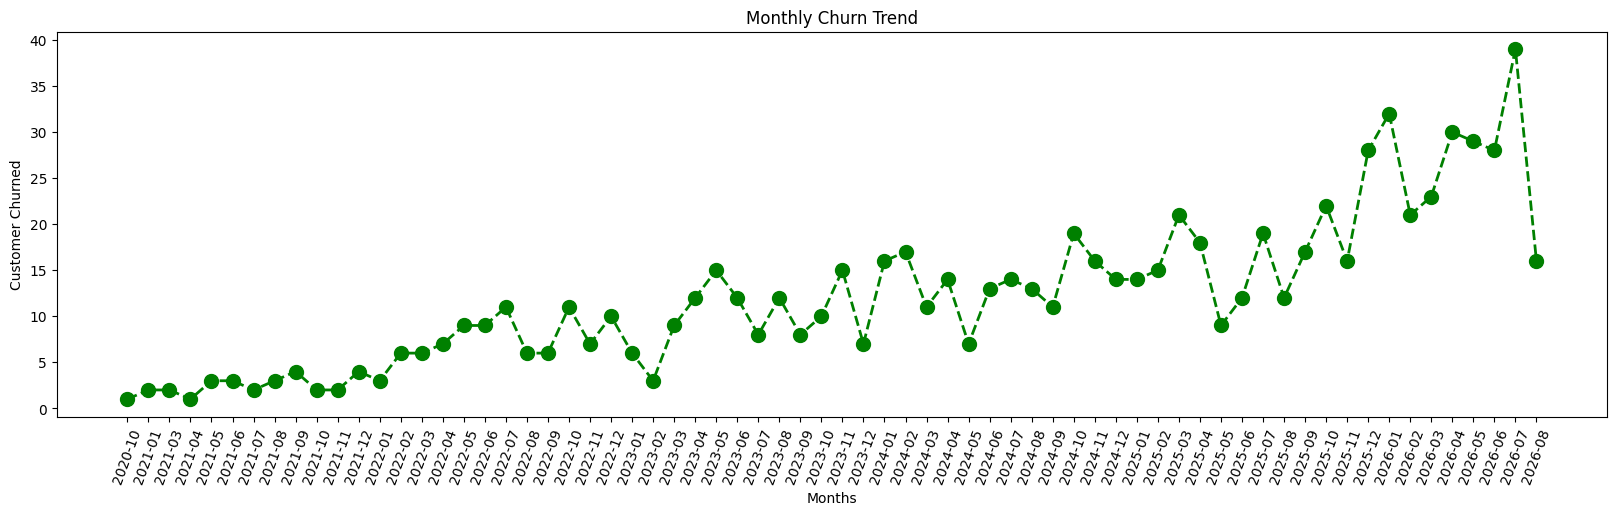

In [57]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')  #creating a column name cancellation month
churn_trend = df_visual[df_visual['churn_flag']== 1].groupby('cancellation_month').size()
plt.figure(figsize = (20,5))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color = 'green',marker ='o',linestyle ='dashed',linewidth = 2,markersize = 10)
plt.title('Monthly Churn Trend')
plt.xlabel('Months')
plt.ylabel('Customer Churned')
plt.xticks(rotation=70)
plt.show()

CHURN BY PLANS

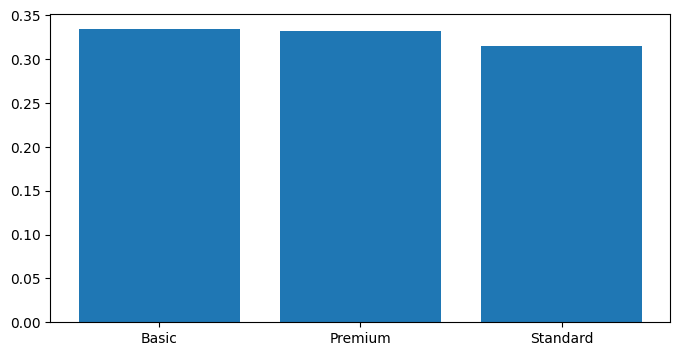

In [58]:
churn_by_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize = (8,4))
plt.bar(churn_by_plan.index.astype(str),churn_by_plan.values)
plt.show()
    

CHURN BY STATES

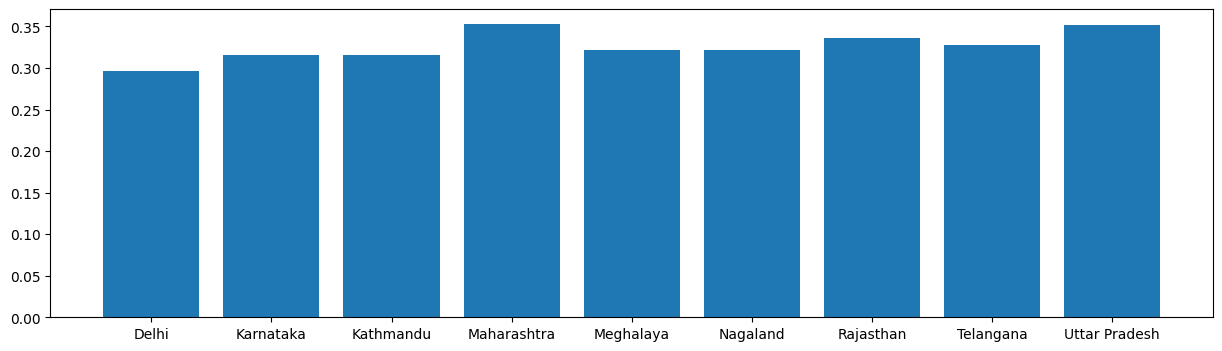

In [59]:
churn_by_states = df_visual.groupby('state')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1,len(churn_by_state)))
plt.figure(figsize = (15,4))
plt.bar(churn_by_states.index.astype(str),churn_by_states.values)
plt.show()


Visualization using seaborn

In [60]:
#Heatmap

In [61]:
# encoding data to int type to create a headmap = based on priority


In [62]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [63]:
df_visual['churn_risk'].unique()

<StringArray>
['low', 'high', 'med']
Length: 3, dtype: str

In [64]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag', 'escalations', 'churn_risk']]

order_mapping = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk' : ['low','med','high']
}
for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories = order,ordered=True).codes
    

In [65]:
df_visual[['plan_type','contract_type', 'churn_score','churn_flag','churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [66]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,0,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

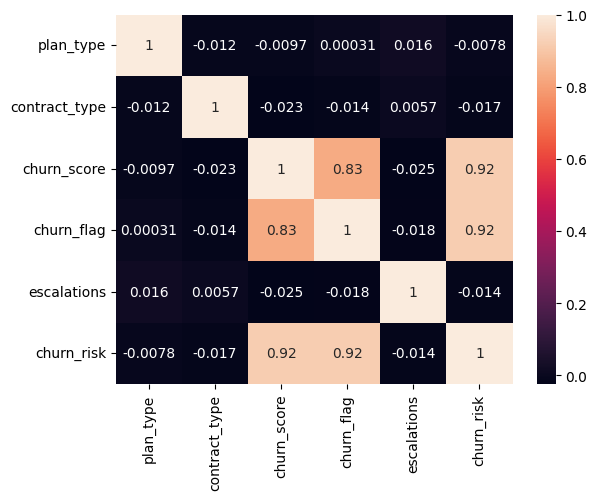

In [67]:
#Heatmap (Correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)

PAIRPLOT

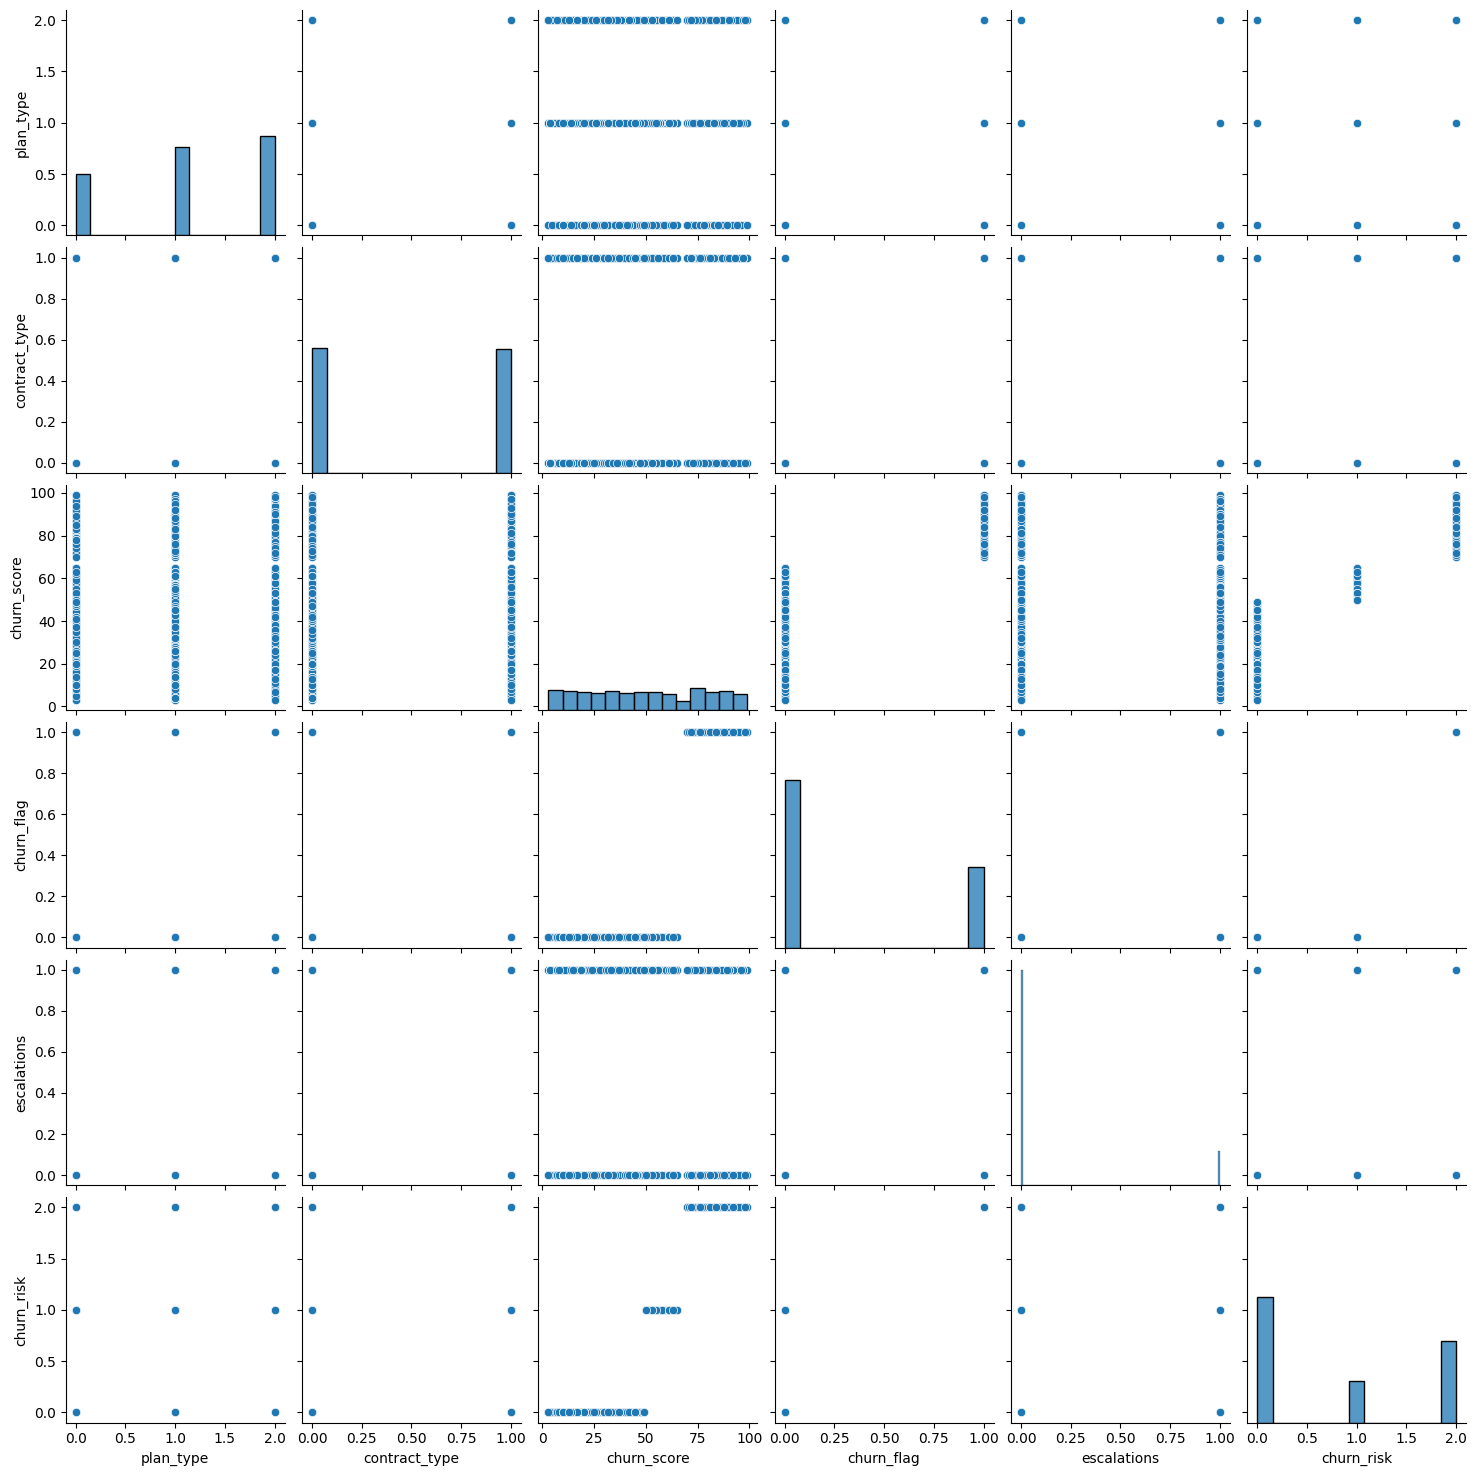

In [68]:
sns.pairplot(df_encoded)

#catplot/Facegrid plot = multi dim comparison


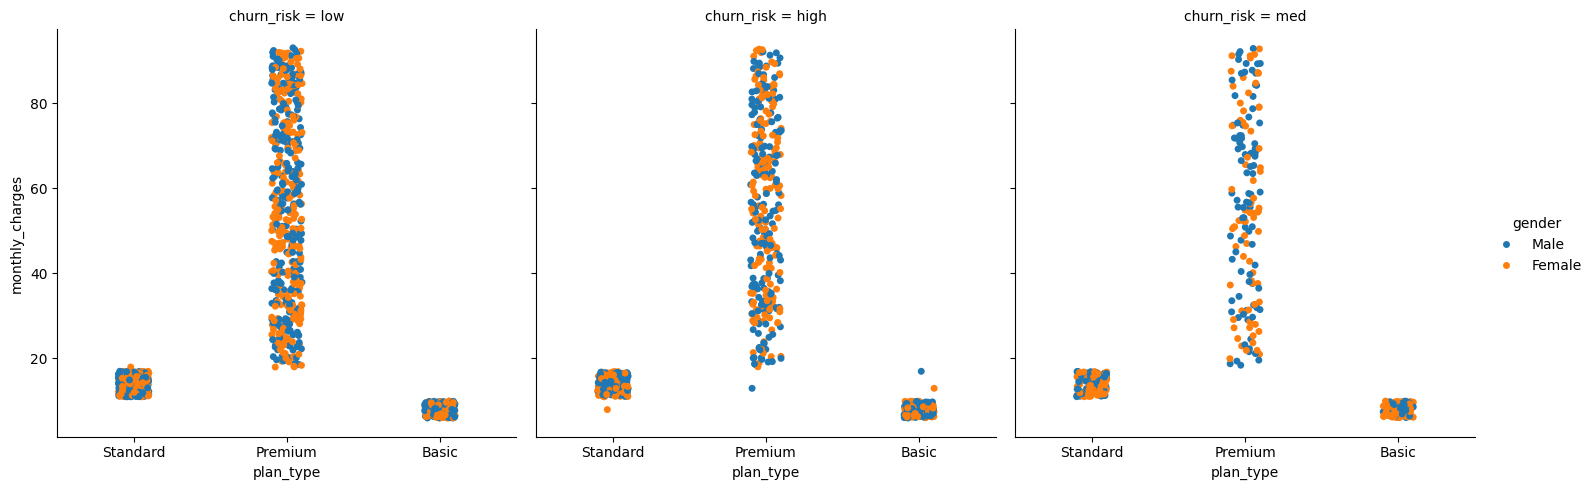

In [69]:
sns.catplot(data = df_visual,
            x ='plan_type',
            y = 'monthly_charges', 
            hue = 'gender',
            col = 'churn_risk')

PIVOT TABLE

In [70]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
).reset_index()
    

,plan_type,churn_flag
0,Basic,0.334405
1,Premium,0.331673
2,Standard,0.315084


In [73]:
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['monthly_charges','customerid','churn_flag'],
    aggfunc ={
        'monthly_charges' : 'sum',
        'customerid' : 'count',
        'churn_flag' : 'mean'}
)
        

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.334405,622,4980.10
Premium,0.331673,1004,55820.80
Standard,0.315084,895,12508.09


Insights

1 #Overall churn

* Churn rate: 32.65% (retention: 67.35%) — a high churn rate for a subscription business, roughly 1 in 3 customers has cancelled.
* Average revenue at risk from already-churned customers: ~24,007 (monthly_charges sum for churned users).
* Average customer tenure: ~927 days (~2.5 years).
* Average revenue per user (ARPU): 29.08.

2 #Churn by plan type — fairly flat, no plan stands out as a major driver:

Basic: 33.44%
Premium: 33.17%
Standard: 31.51%

3 #Churn by state :

Highest: Maharashtra (35.29%) and Uttar Pradesh (35.17%)
Lowest: Delhi (29.62%)
Others cluster in the low-to-mid 30s (Rajasthan 33.61%, Telangana 32.76%, Nagaland/Meghalaya/Kathmandu ~32%, Karnataka 31.56%)

4 #Churn by subscription/acquisition type — also fairly flat:

Paid: 33.16% (and highest revenue contributor: ~32,334)
Organic: 32.22%
Referral: 32.22%

5 #Support/escalation findings — the most notable, and slightly counterintuitive result:

Escalation rate: 13.65% of support tickets
Average complaints per user: 0.54
Correlation between escalations and churn: -0.02 — essentially no linear relationship. This suggests escalations/complaints alone are not a meaningful predictor of churn in this dataset, which is worth flagging since it contradicts the common assumption that support friction drives churn.

****Overall takeaway: Churn here doesn't appear to be strongly explained by plan type, acquisition channel, or support escalations — those are all clustered tightly around 31-35%. State/geography shows the widest spread (Delhi vs. Maharashtra/UP, ~5-6 points apart), which is likely your best lead for further segmentation. The churn_score field (already in your data, used to bucket into low/med/high risk) is probably a stronger predictor than any of the categorical variables you've explored — worth digging into what drives that score, and checking the correlation heatmap/pairplot you generated for churn_score vs. other features.